Image loaded successfully
Image shape: (366, 360, 3)


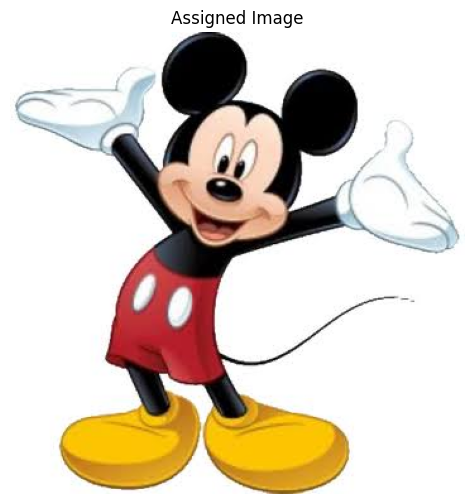

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Your assigned image
IMAGE_PATH = "/content/images.jpg"

# Load image
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError("Image not found. Check the file path.")

print("Image loaded successfully")
print("Image shape:", img.shape)

# Convert BGR to RGB for displaying with Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Assigned Image")
plt.axis("off")
plt.show()

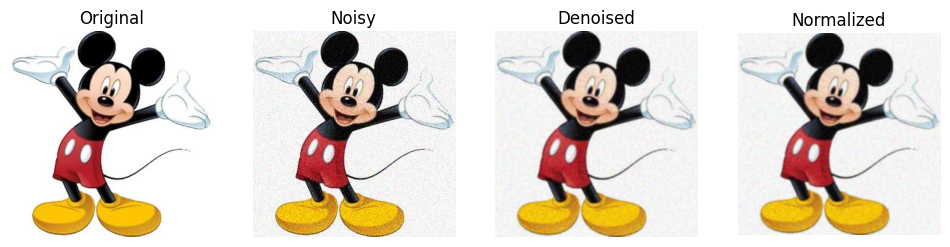

Original: (366, 360, 3)  Resized: (300, 300, 3)
Normalized range: 0.00392156862745098 - 1.0
Observation: Larger Gaussian kernels remove more noise but blur details.


In [10]:
#1. Image Preprocessing Pipeline: Noise Removal, Resizing, and Normalization
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

noise = np.random.normal(0,25,img.shape)
noisy = np.clip(img + noise,0,255).astype(np.uint8)
denoise = cv2.GaussianBlur(noisy,(5,5),0)
resize = cv2.resize(denoise,(300,300))
norm = resize/255.0

plt.figure(figsize=(12,4))
for i,(x,t) in enumerate([(img,"Original"),(noisy,"Noisy"),
                           (denoise,"Denoised"),(norm,"Normalized")]):
    plt.subplot(1,4,i+1); plt.imshow(x); plt.title(t); plt.axis("off")
plt.show()

print("Original:",img.shape," Resized:",resize.shape)
print("Normalized range:",norm.min(),"-",norm.max())
print("Observation: Larger Gaussian kernels remove more noise but blur details.")

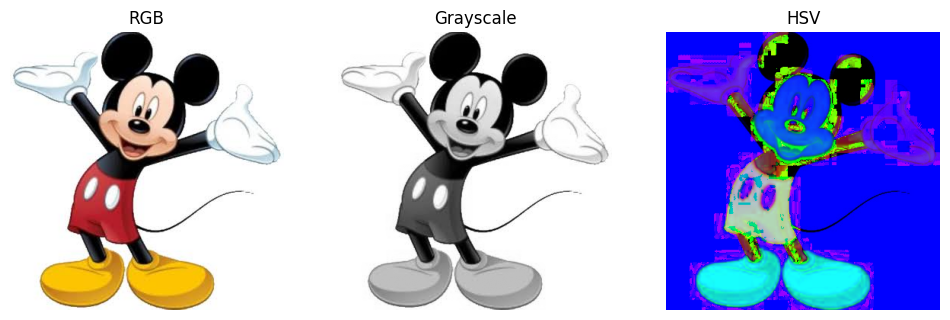

Observation: RGB preserves color, grayscale represents intensity, and HSV separates color from brightness.


In [13]:
#2. Comparative Study of Image Representation Formats (RGB, Grayscale, HSV)
import cv2, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,4))
for i,(x,t,c) in enumerate([(rgb,"RGB",None),(gray,"Grayscale","gray"),
                             (hsv,"HSV",None)]):
    plt.subplot(1,3,i+1)
    plt.imshow(x,cmap=c); plt.title(t); plt.axis("off")
plt.show()

print("Observation: RGB preserves color, grayscale represents intensity, and HSV separates color from brightness.")

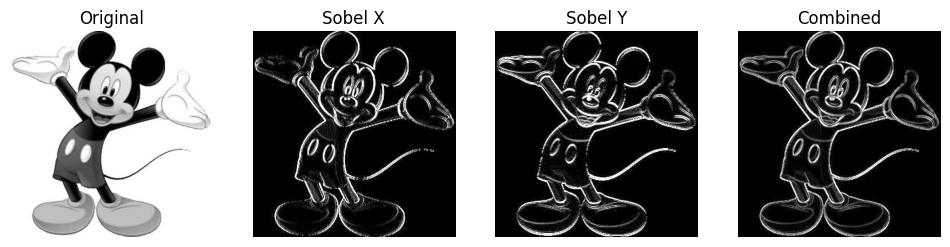

Observation: Sobel detects horizontal and vertical intensity changes.


In [12]:
# 3. Edge Detection Using the Sobel Operator
import cv2, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg",0)

sx = cv2.convertScaleAbs(cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3))
sy = cv2.convertScaleAbs(cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3))
sobel = cv2.addWeighted(sx,.5,sy,.5,0)

plt.figure(figsize=(12,4))
for i,(x,t) in enumerate([(img,"Original"),(sx,"Sobel X"),
                           (sy,"Sobel Y"),(sobel,"Combined")]):
    plt.subplot(1,4,i+1); plt.imshow(x,cmap="gray")
    plt.title(t); plt.axis("off")
plt.show()

print("Observation: Sobel detects horizontal and vertical intensity changes.")

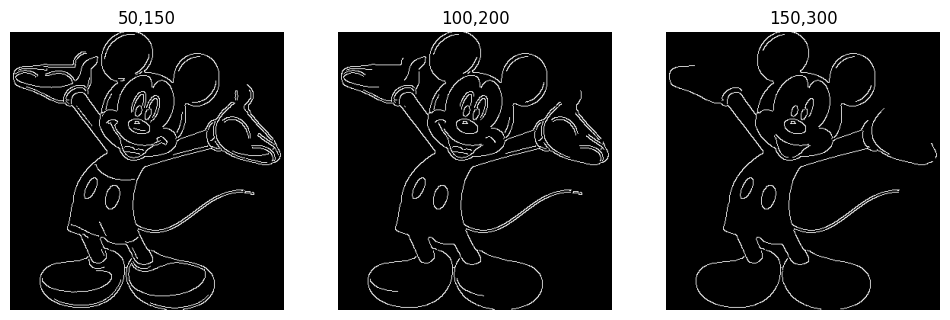

Observation: Lower thresholds detect more edges; higher thresholds produce cleaner but fewer edges.


In [14]:
#4. Edge Detection Using the Canny Algorithm and Parameter Tuning
import cv2, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg",0)
img = cv2.GaussianBlur(img,(5,5),0)

params = [(50,150),(100,200),(150,300)]

plt.figure(figsize=(12,4))
for i,(l,h) in enumerate(params):
    edge = cv2.Canny(img,l,h)
    plt.subplot(1,3,i+1)
    plt.imshow(edge,cmap="gray")
    plt.title(f"{l},{h}"); plt.axis("off")
plt.show()

print("Observation: Lower thresholds detect more edges; higher thresholds produce cleaner but fewer edges.")

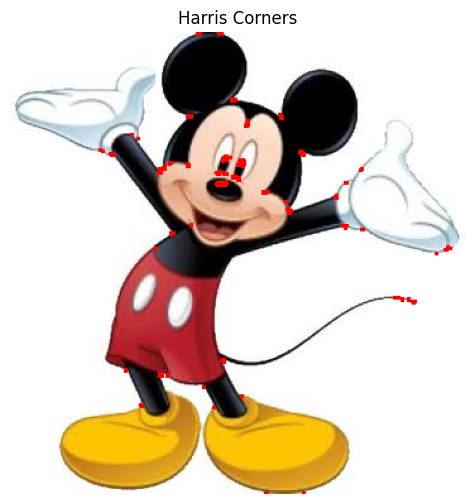

Corners detected: 924
Observation: Harris detects points where intensity changes strongly in multiple directions.


In [15]:
#5. Corner Detection Using the Harris Corner Detector
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

dst = cv2.cornerHarris(np.float32(gray),2,3,.04)
dst = cv2.dilate(dst,None)

result = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
result[dst > .01*dst.max()] = [255,0,0]

plt.figure(figsize=(8,6))
plt.imshow(result); plt.title("Harris Corners"); plt.axis("off")
plt.show()

print("Corners detected:",np.sum(dst > .01*dst.max()))
print("Observation: Harris detects points where intensity changes strongly in multiple directions.")

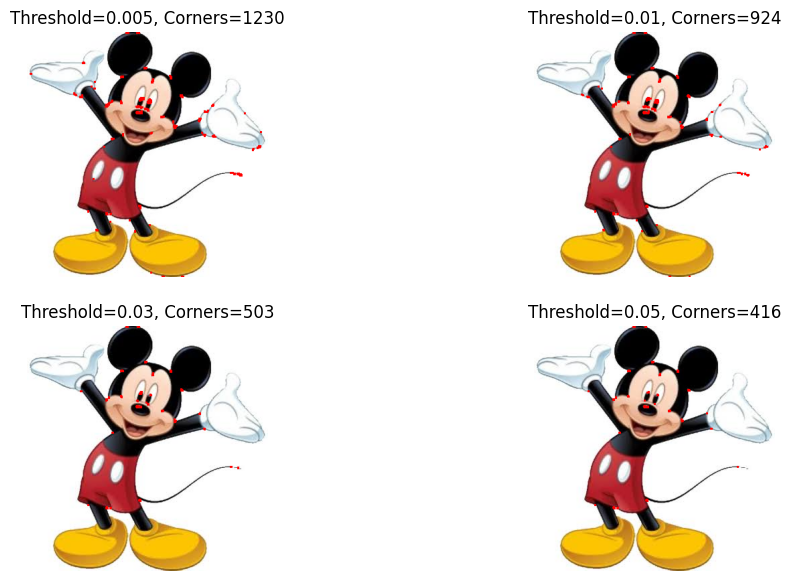

Observation: Increasing threshold reduces the number of detected corners.


In [16]:
#6. Corner Response Analysis Across Varying Threshold Values
import cv2, numpy as np, matplotlib.pyplot as plt
img = cv2.imread("/content/images.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

dst = cv2.dilate(cv2.cornerHarris(np.float32(gray),2,3,.04),None)
thresholds = [.005,.01,.03,.05]

plt.figure(figsize=(12,7))
for i,t in enumerate(thresholds):
    out = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    mask = dst > t*dst.max()
    out[mask] = [255,0,0]

    plt.subplot(2,2,i+1)
    plt.imshow(out)
    plt.title(f"Threshold={t}, Corners={mask.sum()}")
    plt.axis("off")
plt.show()

print("Observation: Increasing threshold reduces the number of detected corners.")

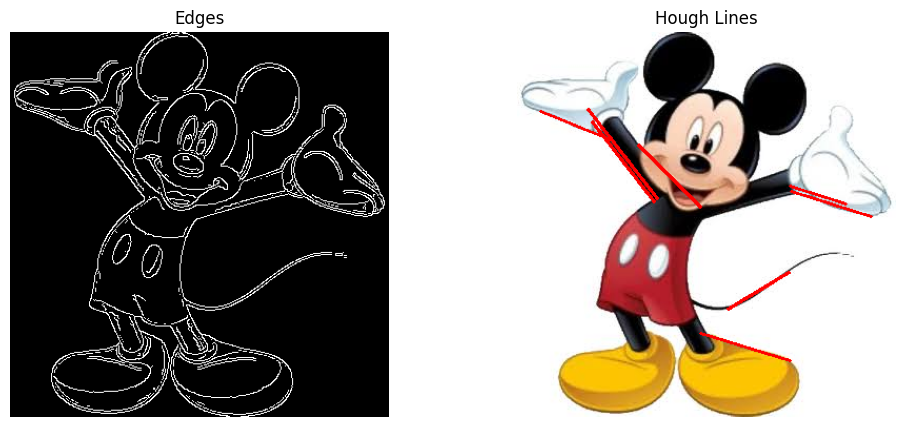

Lines detected: 8
Observation: Higher Hough threshold detects fewer, stronger lines.


In [19]:
#7. Line Detection Using the Hough Transform
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,1,np.pi/180,80,
                        minLineLength=50,maxLineGap=10)

out = img.copy()

if lines is not None:
    for l in lines:
        x1,y1,x2,y2 = l # Changed from l[0] to l
        cv2.line(out,(x1,y1),(x2,y2),(0,0,255),2)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(edges,cmap="gray"); plt.title("Edges")
plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title("Hough Lines"); plt.axis("off")
plt.show()

print("Lines detected:",0 if lines is None else len(lines))
print("Observation: Higher Hough threshold detects fewer, stronger lines.")

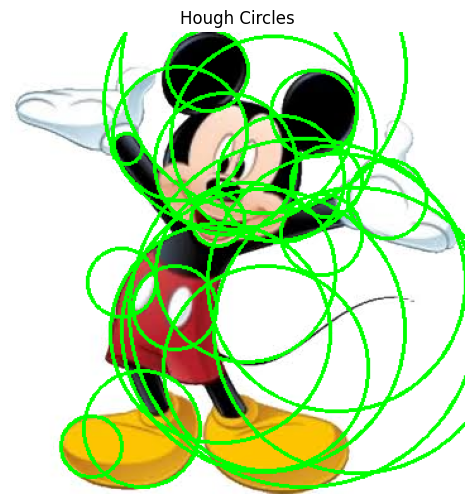

Circles detected: 24
Observation: Lower param2 detects more circles but may produce false detections.


In [18]:
#8. Circle Detection Using the Hough Circle Transform
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
gray = cv2.medianBlur(cv2.cvtColor(img,cv2.COLOR_BGR2GRAY),5)

circles = cv2.HoughCircles(
    gray,cv2.HOUGH_GRADIENT,1,30,
    param1=100,param2=30,
    minRadius=10,maxRadius=150
)

out = img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(out,(x,y),r,(0,255,0),2)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title("Hough Circles"); plt.axis("off")
plt.show()

print("Circles detected:",0 if circles is None else len(circles[0]))
print("Observation: Lower param2 detects more circles but may produce false detections.")

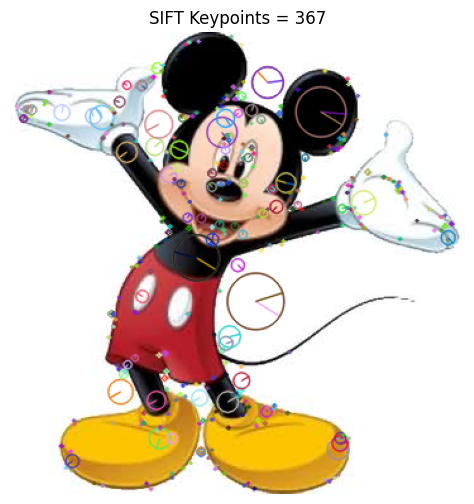

Keypoints: 367
Descriptor shape: (367, 128)
Observation: SIFT extracts distinctive local features that are robust to scale and rotation.


In [20]:
#9. Scale-Invariant Feature Matching Using SIFT Keypoints and Descriptors
import cv2, matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp,des = sift.detectAndCompute(gray,None)

out = cv2.drawKeypoints(
    img,kp,None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints = {len(kp)}")
plt.axis("off")
plt.show()

print("Keypoints:",len(kp))
print("Descriptor shape:",des.shape)
print("Observation: SIFT extracts distinctive local features that are robust to scale and rotation.")

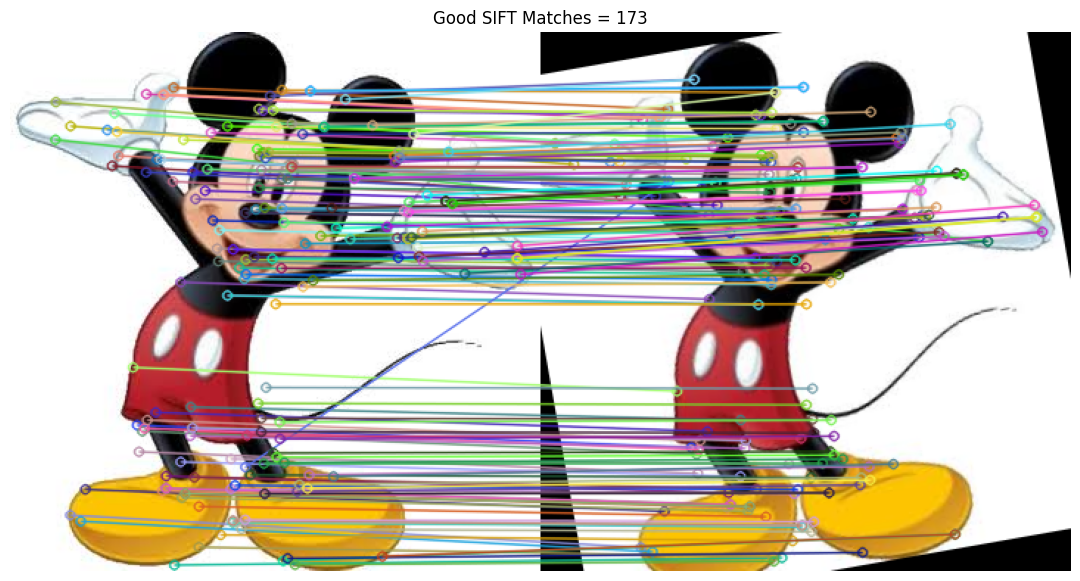

Image 1 keypoints: 367
Image 2 keypoints: 385
Good matches: 173
Observation: A lower ratio is stricter; increasing the ratio gives more but potentially less reliable matches.


In [21]:
#10. Feature Matching Between Two Images Using SIFT and a Distance-Ratio Test
import cv2, numpy as np, matplotlib.pyplot as plt

img1 = cv2.imread("/content/images.jpg")
h,w = img1.shape[:2]

M = cv2.getRotationMatrix2D((w//2,h//2),10,1)
img2 = cv2.warpAffine(img1,M,(w,h))

sift = cv2.SIFT_create()
kp1,d1 = sift.detectAndCompute(cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY),None)
kp2,d2 = sift.detectAndCompute(cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY),None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(d1,d2,k=2)

good = [m for m,n in matches if m.distance < .7*n.distance]

out = cv2.drawMatches(
    img1,kp1,img2,kp2,good,None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,7))
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title(f"Good SIFT Matches = {len(good)}")
plt.axis("off")
plt.show()

print("Image 1 keypoints:",len(kp1))
print("Image 2 keypoints:",len(kp2))
print("Good matches:",len(good))
print("Observation: A lower ratio is stricter; increasing the ratio gives more but potentially less reliable matches.")

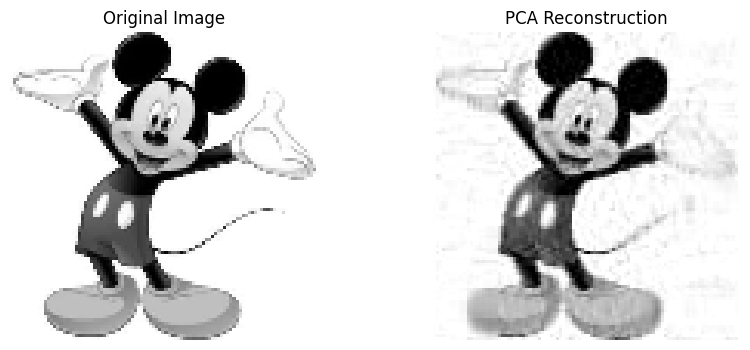

Original dimensions: (100, 100)
Reduced dimensions: (100, 20)
Explained variance: 0.95

Observation:
PCA reduces image dimensions while retaining important information.
More components preserve more image details but provide less dimensionality reduction.


In [22]:
#11. Dimensionality Reduction of Image Data Using Principal Component Analysis
import cv2, numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

img = cv2.imread("/content/images.jpg", 0)

# Resize to reduce computation
img = cv2.resize(img, (100, 100))

# PCA on image rows
pca = PCA(n_components=20)
reduced = pca.fit_transform(img)

# Reconstruct image
reconstructed = pca.inverse_transform(reduced)
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap="gray")
plt.title("PCA Reconstruction")
plt.axis("off")

plt.show()

print("Original dimensions:", img.shape)
print("Reduced dimensions:", reduced.shape)
print("Explained variance:", round(pca.explained_variance_ratio_.sum(),3))

print("\nObservation:")
print("PCA reduces image dimensions while retaining important information.")
print("More components preserve more image details but provide less dimensionality reduction.")

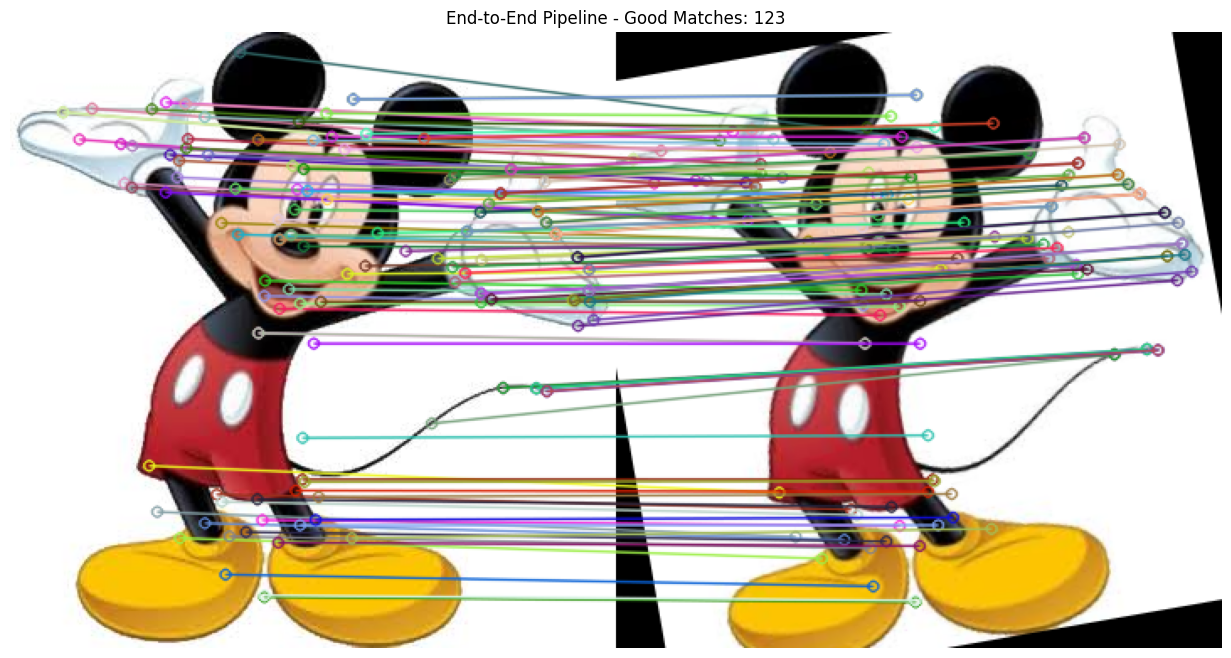

Image 1 keypoints: 197
Image 2 keypoints: 176
Total matches: 197
Good matches: 123

Pipeline:
Preprocessing → SIFT → Descriptors → Matching → Ratio Test → Matched Keypoints

Observation:
The complete pipeline extracts distinctive features and identifies corresponding points between the original and transformed images.


In [23]:
#12. End-to-End Feature Pipeline: From Preprocessing to Matched Keypoints
import cv2, numpy as np, matplotlib.pyplot as plt

# Load image
img1 = cv2.imread("/content/images.jpg")

# Create second related image
h,w = img1.shape[:2]
M = cv2.getRotationMatrix2D((w//2,h//2),10,1)
img2 = cv2.warpAffine(img1,M,(w,h))

# Preprocessing
gray1 = cv2.GaussianBlur(
    cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY),(5,5),0
)
gray2 = cv2.GaussianBlur(
    cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY),(5,5),0
)

# SIFT feature extraction
sift = cv2.SIFT_create()
kp1,des1 = sift.detectAndCompute(gray1,None)
kp2,des2 = sift.detectAndCompute(gray2,None)

# Feature matching
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# Distance-ratio test
good = [m for m,n in matches if m.distance < 0.7*n.distance]

# Draw matched keypoints
result = cv2.drawMatches(
    img1,kp1,img2,kp2,good,None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title(f"End-to-End Pipeline - Good Matches: {len(good)}")
plt.axis("off")
plt.show()

print("Image 1 keypoints:",len(kp1))
print("Image 2 keypoints:",len(kp2))
print("Total matches:",len(matches))
print("Good matches:",len(good))

print("\nPipeline:")
print("Preprocessing → SIFT → Descriptors → Matching → Ratio Test → Matched Keypoints")

print("\nObservation:")
print("The complete pipeline extracts distinctive features and identifies corresponding points between the original and transformed images.")